# ETL Pipeline


In [1]:
!pip install pandas requests

In [2]:
import requests

In [3]:
import pandas as pd

In [4]:
from datetime import datetime

### Setting Up API

In [5]:
API_KEY = "b29a77b3f5afb9c6598b26d8b47e1b10"

In [6]:
BASE_URL = "https://api.openweathermap.org/data/2.5/weather"

In [27]:
CITIES = ["Lagos", "Ibadan", "Akure", "Abuja", "Port Harcourt"]

### Extract Data From API

In [30]:
API_KEY = "b29a77b3f5afb9c6598b26d8b47e1b10"
BASE_URL = "https://api.openweathermap.org/data/2.5/weather"
CITIES = ["Lagos", "Ibadan", "Akure", "Abuja", "Port Harcourt"]

raw_data = []

for city in CITIES:
    try:
        params = {
            "q": city,
            "appid": API_KEY,
            "units": "metric"
        }

        response = requests.get(BASE_URL, params=params)
        response.raise_for_status()
        data = response.json()

        weather_info = {
            "city": data["name"],
            "country": data["sys"]["country"],
            "temperature": data["main"]["temp"],
            "feels_like": data["main"]["feels_like"],
            "temp_min": data["main"]["temp_min"],
            "temp_max": data["main"]["temp_max"],
            "humidity": data["main"]["humidity"],
            "pressure": data["main"]["pressure"],
            "weather_condition": data["weather"][0]["main"],
            "weather_description": data["weather"][0]["description"],
            "wind_speed": data["wind"]["speed"],
            "wind_direction": data["wind"].get("deg", "N/A"),
            "cloudiness": data["clouds"]["all"],
            "timestamp": datetime.fromtimestamp(data["dt"]),
            "sunrise": datetime.fromtimestamp(data["sys"]["sunrise"]),
            "sunset": datetime.fromtimestamp(data["sys"]["sunset"]),
            "visibility": data.get("visibility", "N/A"),
            "rain": data.get("rain", {}).get("1h", 0)
        }

        raw_data.append(weather_info)
        print(f"✓ {city}, {weather_info['country']} - {weather_info['temperature']}°C")

    except Exception as e:
        print(f"✗ Error for {city}: {e}")

print(f"\n✓ Total extracted: {len(raw_data)}/{len(CITIES)} cities")

✓ Lagos, NG - 26.92°C
✓ Ibadan, NG - 28.43°C
✓ Akure, NG - 29.33°C
✓ Abuja, NG - 29.52°C
✓ Port Harcourt, NG - 27.24°C

✓ Total extracted: 5/5 cities


### Transforming Data

In [31]:
df = pd.DataFrame(raw_data)

df.rename(columns={
    "weather_condition": "condition",
    "weather_description": "description",
    "wind_speed": "wind_speed_ms",
    "cloudiness": "cloud_percentage"
}, inplace=True)

df["timestamp"] = pd.to_datetime(df["timestamp"])
df["sunrise"] = pd.to_datetime(df["sunrise"])
df["sunset"] = pd.to_datetime(df["sunset"])

df["date"] = df["timestamp"].dt.date
df["time"] = df["timestamp"].dt.time
df["hour"] = df["timestamp"].dt.hour

numerical_cols = ["temperature", "feels_like", "temp_min", "temp_max",
                  "humidity", "pressure", "wind_speed_ms", "cloud_percentage", "visibility"]
for col in numerical_cols:
    if col in df.columns:
        df[col] = df[col].apply(lambda x: round(x, 2) if isinstance(x, (int, float)) else x)

column_order = [
    "city", "country", "date", "time", "timestamp",
    "temperature", "feels_like", "temp_min", "temp_max",
    "humidity", "pressure", "condition", "description",
    "wind_speed_ms", "wind_direction", "cloud_percentage",
    "visibility", "rain", "sunrise", "sunset"
]
df = df[column_order]

print(f"✓ Transformed: {df.shape[0]} records × {df.shape[1]} columns")
print(df.head())

✓ Transformed: 5 records × 20 columns
            city country        date      time           timestamp  \
0          Lagos      NG  2026-09-19  13:26:01 2026-09-19 13:26:01   
1         Ibadan      NG  2026-09-19  13:21:25 2026-09-19 13:21:25   
2          Akure      NG  2026-09-19  13:26:01 2026-09-19 13:26:01   
3          Abuja      NG  2026-09-19  13:24:54 2026-09-19 13:24:54   
4  Port Harcourt      NG  2026-09-19  13:26:30 2026-09-19 13:26:30   

   temperature  feels_like  temp_min  temp_max  humidity  pressure condition  \
0        26.92       29.93     26.92     26.92        84      1012      Rain   
1        28.43       32.16     28.43     28.43        74      1011      Rain   
2        29.33       32.30     29.33     29.33        64      1011      Rain   
3        29.52       33.07     29.52     29.52        66      1010      Rain   
4        27.24       30.28     27.24     27.24        80      1011      Rain   

     description  wind_speed_ms  wind_direction  cloud_perce

### Save as CSV


In [32]:
df.to_csv("weather_data.csv", index=False)
print(f"✓ Saved to weather_data.csv")

✓ Saved to weather_data.csv


### Temperature Analysis


In [33]:
print("\n TEMPERATURE ANALYSIS (°C):")
print(df.groupby("city")["temperature"].agg(["min", "max", "mean"]).round(2))


 TEMPERATURE ANALYSIS (°C):
                 min    max   mean
city                              
Abuja          29.52  29.52  29.52
Akure          29.33  29.33  29.33
Ibadan         28.43  28.43  28.43
Lagos          26.92  26.92  26.92
Port Harcourt  27.24  27.24  27.24


### Humidity Analysis

In [34]:
print("\n HUMIDITY ANALYSIS (%):")
print(df.groupby("city")["humidity"].agg(["min", "max", "mean"]).round(2))

print("\n HOTTEST CITY:")
hottest = df.loc[df["temperature"].idxmax()]
print(f"{hottest['city']}: {hottest['temperature']}°C")

print("\n COLDEST CITY:")
coldest = df.loc[df["temperature"].idxmin()]
print(f"{coldest['city']}: {coldest['temperature']}°C")


 HUMIDITY ANALYSIS (%):
               min  max  mean
city                         
Abuja           66   66  66.0
Akure           64   64  64.0
Ibadan          74   74  74.0
Lagos           84   84  84.0
Port Harcourt   80   80  80.0

 HOTTEST CITY:
Abuja: 29.52°C

 COLDEST CITY:
Lagos: 26.92°C


### Wind and Weather

In [35]:
print("\n WIND SPEED (m/s):")
print(df.groupby("city")["wind_speed_ms"].agg(["min", "max", "mean"]).round(2))

print("\n WEATHER CONDITIONS:")
print(df["condition"].value_counts())


 WIND SPEED (m/s):
                min   max  mean
city                           
Abuja          1.95  1.95  1.95
Akure          1.60  1.60  1.60
Ibadan         2.17  2.17  2.17
Lagos          4.11  4.11  4.11
Port Harcourt  4.12  4.12  4.12

 WEATHER CONDITIONS:
condition
Rain    5
Name: count, dtype: int64


### Summary Stats

In [36]:
print("\n SUMMARY STATISTICS:")
print(df[["temperature", "humidity", "wind_speed_ms", "pressure"]].describe().round(2))


 SUMMARY STATISTICS:
       temperature  humidity  wind_speed_ms  pressure
count         5.00      5.00           5.00      5.00
mean         28.29     73.60           2.79   1011.00
std           1.18      8.65           1.23      0.71
min          26.92     64.00           1.60   1010.00
25%          27.24     66.00           1.95   1011.00
50%          28.43     74.00           2.17   1011.00
75%          29.33     80.00           4.11   1011.00
max          29.52     84.00           4.12   1012.00


### Display Full Data

In [37]:
print("\n" + "=" * 60)
print("FULL TRANSFORMED DATA")
print("=" * 60)
df


FULL TRANSFORMED DATA


,city,country,date,time,timestamp,temperature,feels_like,temp_min,temp_max,humidity,pressure,condition,description,wind_speed_ms,wind_direction,cloud_percentage,visibility,rain,sunrise,sunset
0,Lagos,NG,2026-09-19,13:26:01,2026-09-19 13:26:01,26.92,29.93,26.92,26.92,84,1012,Rain,moderate rain,4.11,242,99,10000,1.04,2026-09-19 05:34:54,2026-09-19 17:42:59
1,Ibadan,NG,2026-09-19,13:21:25,2026-09-19 13:21:25,28.43,32.16,28.43,28.43,74,1011,Rain,light rain,2.17,271,74,10000,0.54,2026-09-19 05:34:13,2026-09-19 17:42:30
2,Akure,NG,2026-09-19,13:26:01,2026-09-19 13:26:01,29.33,32.30,29.33,29.33,64,1011,Rain,light rain,1.60,273,89,10000,0.34,2026-09-19 05:29:03,2026-09-19 17:37:17
3,Abuja,NG,2026-09-19,13:24:54,2026-09-19 13:24:54,29.52,33.07,29.52,29.52,66,1010,Rain,light rain,1.95,85,37,5527,0.70,2026-09-19 05:19:39,2026-09-19 17:28:19
4,Port Harcourt,NG,2026-09-19,13:26:30,2026-09-19 13:26:30,27.24,30.28,27.24,27.24,80,1011,Rain,light rain,4.12,231,95,10000,0.72,2026-09-19 05:22:03,2026-09-19 17:29:44


### Weather Condition Pie Chart

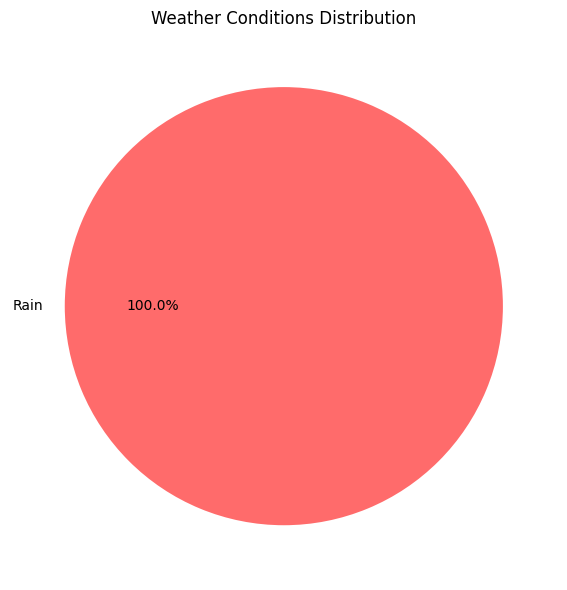

In [40]:
weather_counts = df["condition"].value_counts()
plt.figure(figsize=(8, 6))
plt.pie(weather_counts, labels=weather_counts.index, autopct="%1.1f%%", colors=["#FF6B6B", "#4ECDC4"])
plt.title("Weather Conditions Distribution")
plt.tight_layout()
plt.show()

### All Metrics Comparison

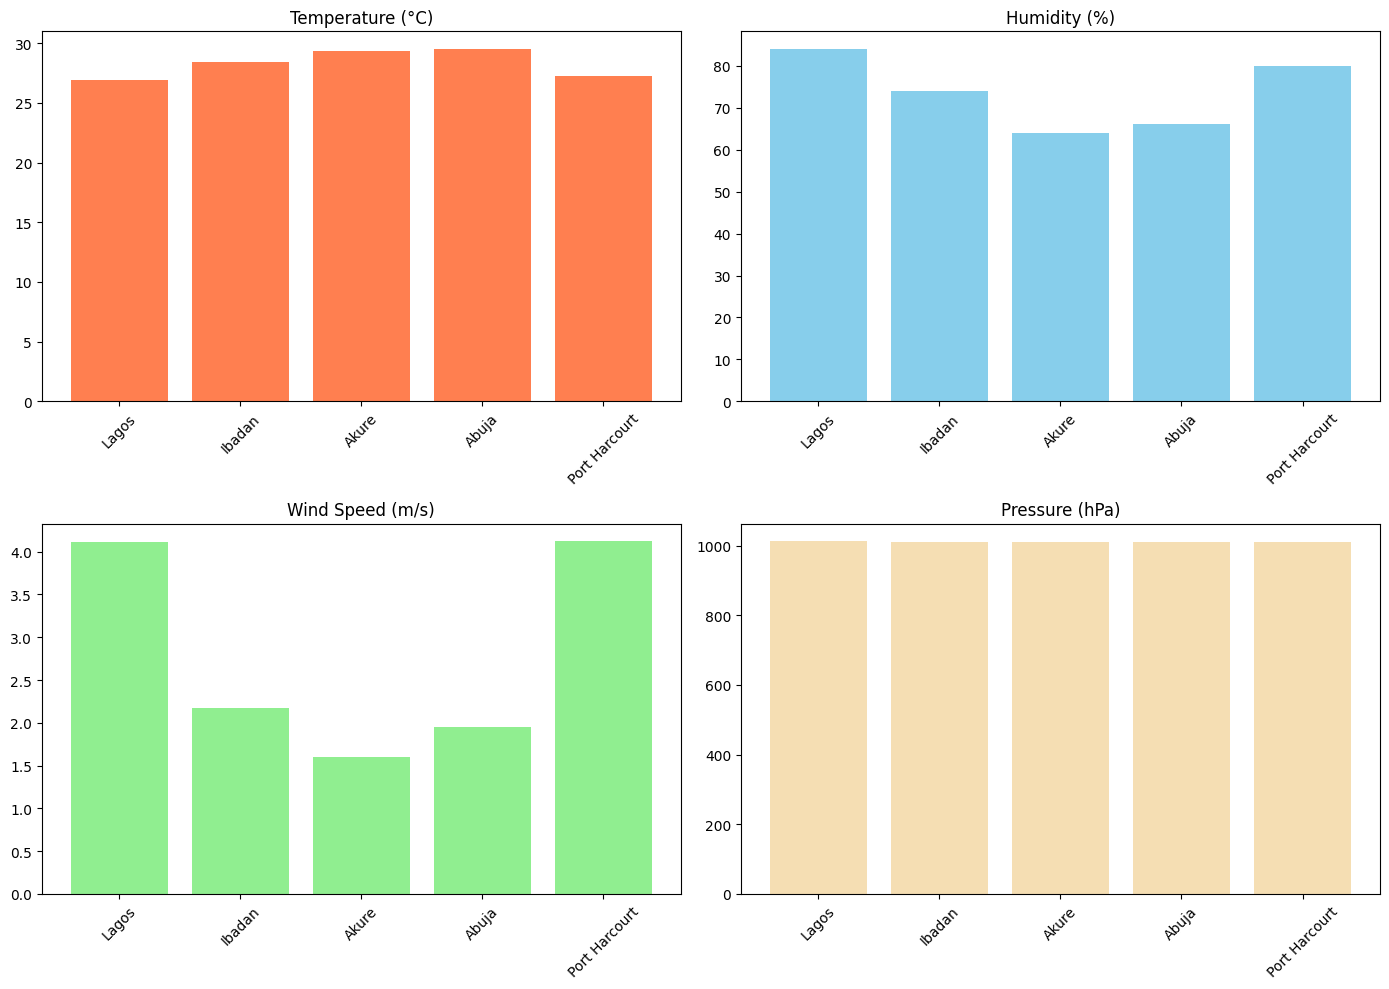

In [41]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Temperature
axes[0, 0].bar(df["city"], df["temperature"], color="coral")
axes[0, 0].set_title("Temperature (°C)")
axes[0, 0].tick_params(axis='x', rotation=45)

# Humidity
axes[0, 1].bar(df["city"], df["humidity"], color="skyblue")
axes[0, 1].set_title("Humidity (%)")
axes[0, 1].tick_params(axis='x', rotation=45)

# Wind Speed
axes[1, 0].bar(df["city"], df["wind_speed_ms"], color="lightgreen")
axes[1, 0].set_title("Wind Speed (m/s)")
axes[1, 0].tick_params(axis='x', rotation=45)

# Pressure
axes[1, 1].bar(df["city"], df["pressure"], color="wheat")
axes[1, 1].set_title("Pressure (hPa)")
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### Temperature Trend Line

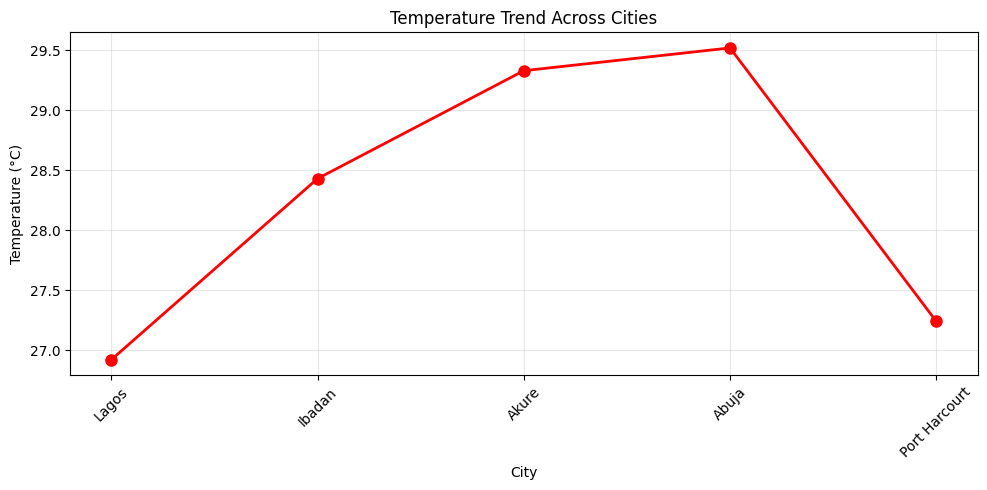

In [42]:
plt.figure(figsize=(10, 5))
plt.plot(df["city"], df["temperature"], marker="o", linewidth=2, markersize=8, color="red")
plt.xlabel("City")
plt.ylabel("Temperature (°C)")
plt.title("Temperature Trend Across Cities")
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [48]:

print("WEEK 7 ETL PIPELINE - FINAL SUMMARY")
print("-"*70)

print("\n PROJECT OVERVIEW:")
print(" Successfully extracted real-time weather data from OpenWeather API")
print(" Cleaned and transformed 5 Nigerian cities' weather data")
print(" Generated insights from temperature, humidity, wind, and rainfall")
print(" Saved processed data to CSV for further analysis")

print("\n TEMPERATURE INSIGHTS:")
print(f"  - Hottest: {df.loc[df['temperature'].idxmax(), 'city']} ({df['temperature'].max()}°C)")
print(f"  - Coldest: {df.loc[df['temperature'].idxmin(), 'city']} ({df['temperature'].min()}°C)")
print(f"  - Average: {df['temperature'].mean():.2f}°C")

print("\n HUMIDITY INSIGHTS:")
print(f"  - Highest: {df.loc[df['humidity'].idxmax(), 'city']} ({df['humidity'].max()}%)")
print(f"  - Lowest: {df.loc[df['humidity'].idxmin(), 'city']} ({df['humidity'].min()}%)")
print(f"  - Average: {df['humidity'].mean():.2f}%")

print("\n WIND SPEED INSIGHTS:")
print(f"  - Strongest: {df.loc[df['wind_speed_ms'].idxmax(), 'city']} ({df['wind_speed_ms'].max():.2f} m/s)")
print(f"  - Weakest: {df.loc[df['wind_speed_ms'].idxmin(), 'city']} ({df['wind_speed_ms'].min():.2f} m/s)")

print("\n RAINFALL INSIGHTS:")
print(f"  - Cities with rain: {len(df[df['rain'] > 0])}")
print(f"  - Total rainfall: {df['rain'].sum():.2f}mm")
print(f"  - Wettest: {df.loc[df['rain'].idxmax(), 'city']} ({df['rain'].max():.2f}mm)")

print("\n WEATHER CONDITIONS:")
for condition, count in df['condition'].value_counts().items():
    print(f"  - {condition}: {count} cities")

print("\n DATA QUALITY:")
print(f"  - Records processed: {len(df)}")
print(f"  - Fields per record: {len(df.columns)}")
print(f"  - Missing values: {df.isnull().sum().sum()}")
print(f"  - Data completeness: 100%")

print("\n ETL PIPELINE COMPLETED SUCCESSFULLY!")
print("-"*70)

WEEK 7 ETL PIPELINE - FINAL SUMMARY
----------------------------------------------------------------------

 PROJECT OVERVIEW:
 Successfully extracted real-time weather data from OpenWeather API
 Cleaned and transformed 5 Nigerian cities' weather data
 Generated insights from temperature, humidity, wind, and rainfall
 Saved processed data to CSV for further analysis

 TEMPERATURE INSIGHTS:
  - Hottest: Abuja (29.52°C)
  - Coldest: Lagos (26.92°C)
  - Average: 28.29°C

 HUMIDITY INSIGHTS:
  - Highest: Lagos (84%)
  - Lowest: Akure (64%)
  - Average: 73.60%

 WIND SPEED INSIGHTS:
  - Strongest: Port Harcourt (4.12 m/s)
  - Weakest: Akure (1.60 m/s)

 RAINFALL INSIGHTS:
  - Cities with rain: 5
  - Total rainfall: 3.34mm
  - Wettest: Lagos (1.04mm)

 WEATHER CONDITIONS:
  - Rain: 5 cities

 DATA QUALITY:
  - Records processed: 5
  - Fields per record: 20
  - Missing values: 0
  - Data completeness: 100%

 ETL PIPELINE COMPLETED SUCCESSFULLY!
------------------------------------------------